# scCS Tutorial — Pairwise Condition Comparison
## Multi-Condition Commitment Score Analysis with `MultiConditionScorer`

This notebook demonstrates the **multi-condition analysis** workflow in scCS v0.5.0.

We artificially split the pancreas dataset into two groups:
- **"high_velocity"** — cells with above-median RNA velocity magnitude (stronger commitment signal)
- **"low_velocity"** — cells with below-median RNA velocity magnitude (weaker commitment signal)

This simulates a treatment effect where one condition drives stronger fate commitment.

### Three-tier analysis framework

| Tier | What it answers | Key functions |
|------|----------------|---------------|
| **Tier 1** | What are the commitment scores per condition? | `score_all_conditions()`, `plot_condition_star()` |
| **Tier 2** | Is the difference statistically significant? | `compute_delta_CS()`, `compare_conditions()`, `plot_condition_comparison()` |
| **Tier 3** | Does the trajectory shift between conditions? | `fit_mixed_model()`, `trajectory_shift()`, `plot_trajectory_shift()` |

### Reference
Kriukov et al. (2025) *Single-cell transcriptome of myeloid cells in response to transplantation of human retinal neurons reveals reversibility of microglial activation*


## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import scCS

print(f"scCS version: {scCS.__version__}")

sc.settings.verbosity = 1
scv.settings.verbosity = 1

scCS version: 0.5.0


In [3]:
# Load the pancreas dataset
adata = scv.datasets.pancreas()

# Standard preprocessing
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
sc.pp.neighbors(adata)
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

print(adata)

/home/baranov_lab/anaconda3/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu'
    obsp: 'distances', 'connectivities'


In [4]:
# Run RNA velocity (dynamical model)
scv.tl.recover_dynamics(adata, n_jobs=32)
scv.tl.velocity(adata, mode="dynamical")
scv.tl.velocity_graph(adata)
scv.tl.velocity_pseudotime(adata)

print("Velocity computed.")

  0%|          | 0/1139 [00:00<?, ?gene/s]

  0%|          | 0/3696 [00:00<?, ?cells/s]

Velocity computed.


## 2. Create artificial condition split

We split cells into two groups based on their **RNA velocity magnitude**:
- **high_velocity** — cells with above-median velocity magnitude
- **low_velocity** — cells with below-median velocity magnitude

This simulates a scenario where a treatment (e.g., a drug or genetic perturbation)
increases the strength of fate commitment signals.

> In a real experiment, `condition_key` would point to a column like `'treatment'`,
> `'genotype'`, or `'time_point'` already present in `adata.obs`.


In [5]:
# Compute per-cell velocity magnitude from the velocity layer
velocity_matrix = adata.layers["velocity"]  # shape: (n_cells, n_genes)
# Use RMS across genes as a per-cell magnitude proxy
vel_magnitude = np.sqrt(np.nanmean(velocity_matrix ** 2, axis=1))

# Split at the median
median_mag = np.median(vel_magnitude)
adata.obs["condition"] = np.where(
    vel_magnitude >= median_mag, "high_velocity", "low_velocity"
)

# Also create a fake replicate column (for mixed model demo)
# In practice this would be biological replicates / samples
np.random.seed(42)
adata.obs["sample"] = np.random.choice(
    ["rep1", "rep2", "rep3"], size=adata.n_obs
)

print("Condition distribution:")
print(adata.obs["condition"].value_counts())
print("\nSample distribution:")
print(adata.obs["sample"].value_counts())

Condition distribution:
high_velocity    1848
low_velocity     1848
Name: condition, dtype: int64

Sample distribution:
rep1    1282
rep2    1224
rep3    1190
Name: sample, dtype: int64


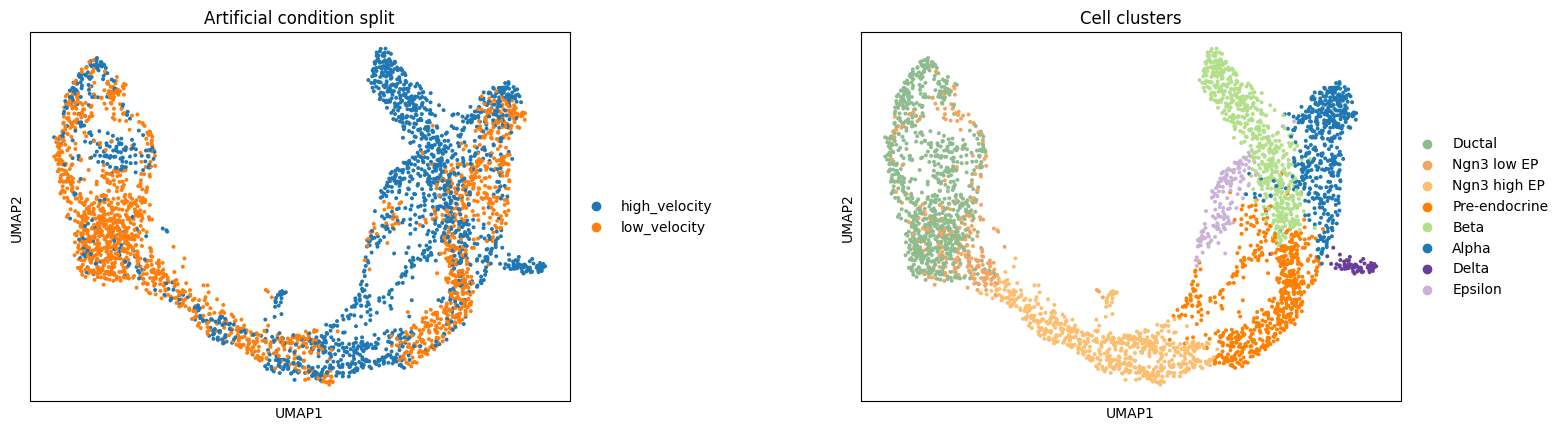

In [6]:
# Visualize the split on UMAP
sc.pl.umap(adata, color=["condition", "clusters"], ncols=2, wspace=0.4,
           title=["Artificial condition split", "Cell clusters"])

In [7]:
# Confirm both conditions contain bifurcation + terminal fate cells
for cond in ["high_velocity", "low_velocity"]:
    sub = adata[adata.obs["condition"] == cond]
    clusters_present = sub.obs["clusters"].unique().tolist()
    print(f"\n{cond}: {sub.n_obs} cells")
    print(f"  Clusters: {sorted(clusters_present)}")


high_velocity: 1848 cells
  Clusters: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine']

low_velocity: 1848 cells
  Clusters: ['Alpha', 'Beta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine']


## 3. Initialize `MultiConditionScorer`

`MultiConditionScorer` wraps `CommitmentScorer` and builds a **shared embedding**
on pooled data from all conditions.  This ensures that arm geometry is identical
across conditions — a prerequisite for valid cross-condition comparison.

Key parameters:
- `condition_key` — column in `adata.obs` with condition labels
- All other parameters are identical to `CommitmentScorer`


In [8]:
mscorer = scCS.MultiConditionScorer(
    adata,
    bifurcation_cluster="Pre-endocrine",
    terminal_cell_types=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_key="condition",   # our artificial split
    cluster_key="clusters",
    n_bins=36,
    sector_mode="centroid",
)

[scCS] MultiConditionScorer initialized.
       Conditions (2): ['high_velocity', 'low_velocity']
       Bifurcation: 'Pre-endocrine', Fates: ['Alpha', 'Beta', 'Delta', 'Epsilon']


## 4. Build the shared star embedding

The embedding is built on **all cells pooled** across conditions.
This guarantees that the arm directions are the same for both conditions.

We then fix arm coverage using subset-local pseudotime.
For multi-condition analysis, we use `scale_01=False` to preserve
absolute pseudotime ordering across conditions.


In [9]:
# Build shared embedding on pooled data
mscorer.build_embedding(
    differentiation_metric="pseudotime",
    arm_scale=10.0,
    jitter=0.3,
)

# Fix arm coverage — use scale_01=False for cross-condition comparability
mscorer.rebuild_embedding_with_subset_pseudotime(scale_01=True)

print("Shared embedding built.")
print(f"Cells in embedding: {mscorer.adata_sub.n_obs}")
print("Condition distribution in embedding:")
print(mscorer.adata_sub.obs["condition"].value_counts())

[scCS] Building SHARED embedding on pooled data (3696 cells, 2 conditions)...
[scCS] Building star embedding: bifurcation='Pre-endocrine', k=4 fates, metric='pseudotime'
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Delta': 180.0, 'Epsilon': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1876 cells)
[scCS] Recomputing pseudotime on subset (1876 / 3696 cells)...
[scCS] Used scanpy DPT as pseudotime fallback.
[scCS] Subset pseudotime scaled to [0, 1].
[scCS] Subset pseudotime stored in adata_sub.obs['velocity_pseudotime_sub']. Range: [nan, nan]
[scCS] Rebuilding star embedding with subset-local pseudotime...
[scCS] Subsetting: 18

## 5. Fit the shared FateMap

In [10]:
mscorer.fit()

[scCS] Bifurcation cluster 'Pre-endocrine': 592 cells, centroid=(-0.00, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(5.00, -0.01)
[scCS]   Fate 'Beta': 591 cells, centroid=(0.03, 5.00)
[scCS]   Fate 'Delta': 70 cells, centroid=(-5.00, -0.05)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(-0.02, -5.00)
[scCS] FateMap built: k=4 fates
[scCS] Projecting velocity via scVelo on full adata → slicing to subset...
[scCS] Velocity projected. Shape: (1876, 2)
FateMap  (bifurcation_cluster='Pre-endocrine', k=4)
  Cluster key : 'clusters'
  Root cells  : 592
  Root centroid: (-0.005, -0.003)
  Fate 0: 'Alpha'  n_cells=481  centroid=(5.00, -0.01)  arm_angle=0.0°
  Fate 1: 'Beta'  n_cells=591  centroid=(0.03, 5.00)  arm_angle=90.0°
  Fate 2: 'Delta'  n_cells=70  centroid=(-5.00, -0.05)  arm_angle=180.0°
  Fate 3: 'Epsilon'  n_cells=142  centroid=(-0.02, -5.00)  arm_angle=270.0°


## Tier 1: Score each condition on the shared embedding

`score_all_conditions()` computes commitment scores separately for each condition,
using the shared embedding and FateMap.  Each condition's cells are masked from
the shared `adata_sub`.


In [11]:
# Score all conditions
results = mscorer.score_all_conditions(
    compute_cell_level=True,
    k_nn=15,
    n_bootstrap=200,   # bootstrap CI per condition
    bootstrap_ci=0.95,
    verbose=True,
)


[scCS] Scoring condition: 'high_velocity' (1219 cells)...
[scCS] Computing bootstrap CI (n=200)...
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Delta, Epsilon
  Dominant fate: Beta

  Entropy metrics:
    Population entropy:           0.9410  [aggregate velocity-mass balance]
    Mean cell entropy:            0.9736  [per-cell average, k-way]
    Per-fate cell entropy:
      Alpha: 0.8214
      Beta: 0.8153
      Delta: 0.7736
      Epsilon: 0.7654
    NN-smoothed entropy (k=15):  mean=0.9940  [per-cell, stored in adata_sub.obs['cs_nn_entropy']]

  Commitment vector (normalized):
    Alpha: 0.2596
    Beta: 0.3943
    Delta: 0.1153
    Epsilon: 0.2307

  Pairwise nCS matrix:
            Alpha      Beta     Delta   Epsilon
Alpha    1.000000  1.498013  0.700209  0.575007
Beta     0.667551  1.000000  0.467425  0.383846
Delta    1.428144  2.139378  1.000000  0.821192
Epsilon  1.739110  2.605209  1.217741  1.000000

  Bootstrap 95% CI on nCS (n=200):
    CI low:
         Alpha  

In [12]:
# Compare nCS matrices side by side
for cond, res in results.items():
    print(f"\n=== {cond} ===")
    print(pd.DataFrame(
        res.pairwise_nCS,
        index=res.fate_names,
        columns=res.fate_names
    ).round(3))


=== high_velocity ===
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  1.498  0.700    0.575
Beta     0.668  1.000  0.467    0.384
Delta    1.428  2.139  1.000    0.821
Epsilon  1.739  2.605  1.218    1.000

=== low_velocity ===
         Alpha   Beta  Delta  Epsilon
Alpha    1.000  0.201    0.0    0.473
Beta     4.981  1.000    0.0    2.358
Delta      inf    inf    1.0      inf
Epsilon  2.112  0.424    0.0    1.000


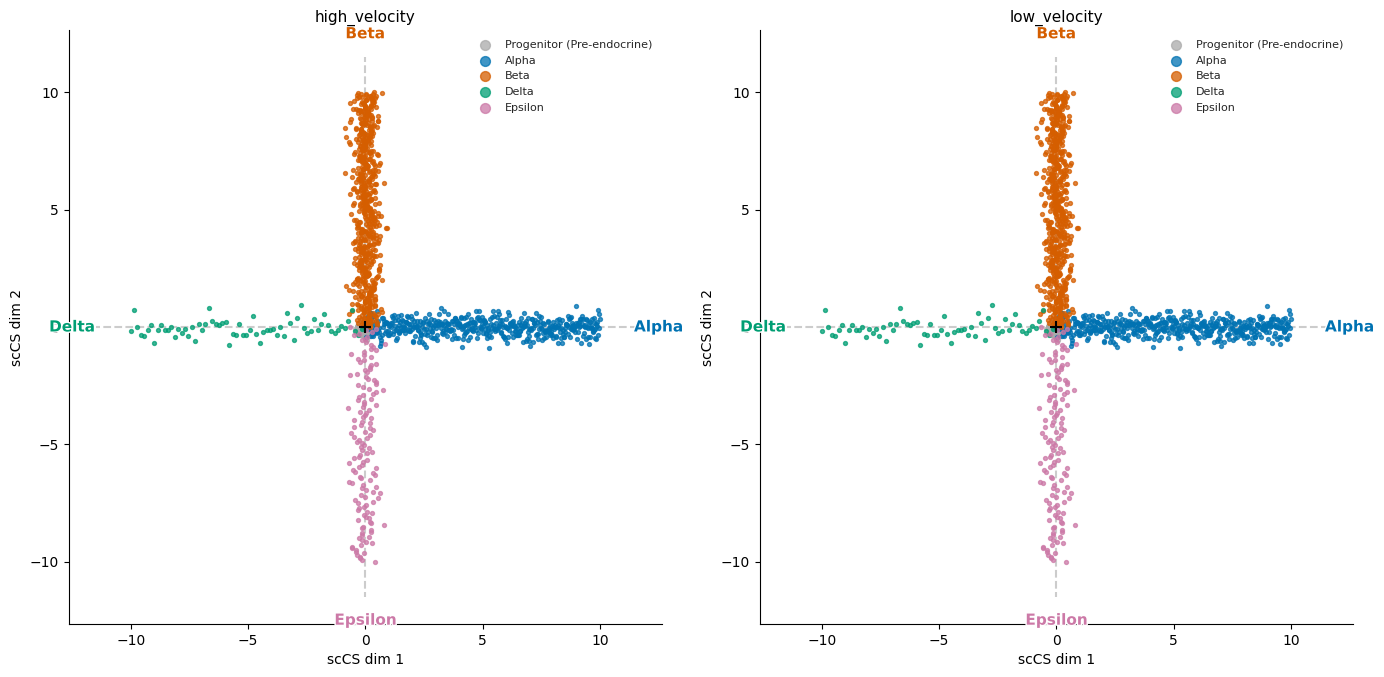

In [13]:
# Side-by-side star plots for each condition
# figsize_per_panel controls the size of each individual panel
fig = mscorer.plot_condition_star(
    results,
    figsize_per_panel=(7, 7),
)
plt.tight_layout()
plt.show()

In [14]:
# Commitment vectors per condition
print("Commitment vectors (fraction of velocity mass per fate):")
for cond, res in results.items():
    print(f"\n  {cond}:")
    for fate, cv in zip(res.fate_names, res.commitment_vector):
        print(f"    {fate}: {cv:.3f}")

Commitment vectors (fraction of velocity mass per fate):

  high_velocity:
    Alpha: 0.260
    Beta: 0.394
    Delta: 0.115
    Epsilon: 0.231

  low_velocity:
    Alpha: 0.324
    Beta: 0.498
    Delta: 0.106
    Epsilon: 0.072


## Tier 2: Statistical comparison

### 2a. ΔCS with bootstrap confidence intervals

`compute_delta_CS()` computes ΔnCS = nCS_A − nCS_B for each fate pair,
with bootstrap CIs obtained by resampling cells within each condition.

A CI that does not include 0 indicates a statistically meaningful difference.


In [15]:
# Compute ΔCS: high_velocity − low_velocity
delta = mscorer.compute_delta_CS(
    condition_a="high_velocity",
    condition_b="low_velocity",
    n_bootstrap=500,
    ci=0.95,
    verbose=True,
)


=== ΔCS: 'high_velocity' − 'low_velocity' ===
  ΔnCS (point estimate):
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  1.297  0.700    0.102
Beta    -4.313  0.000  0.467   -1.974
Delta     -inf   -inf  0.000     -inf
Epsilon -0.373  2.181  1.218    0.000

  95% CI low:
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  1.099  0.589   -0.050
Beta    -5.266  0.000  0.384   -2.684
Delta      NaN    NaN  0.000      NaN
Epsilon -0.990  1.814  1.036    0.000

  95% CI high:
         Alpha   Beta  Delta  Epsilon
Alpha    0.000  1.548  0.836    0.237
Beta    -3.533  0.000  0.559   -1.511
Delta      NaN    NaN  0.000      NaN
Epsilon  0.152  2.647  1.468    0.000


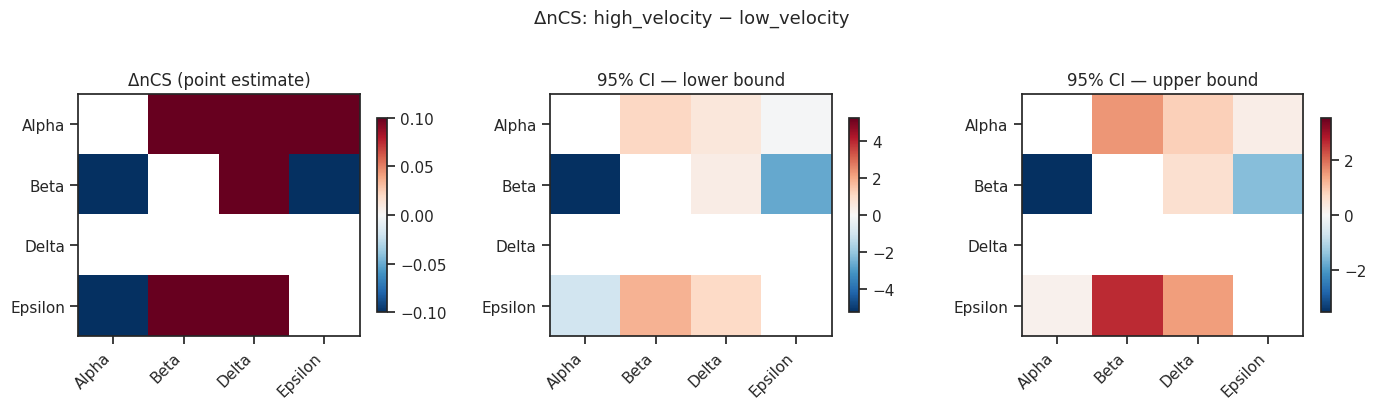

In [16]:
# Visualize ΔCS as a heatmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fate_names = delta["fate_names"]
k = len(fate_names)
delta_mat = delta["delta_nCS"]
ci_low = delta["ci_low"]
ci_high = delta["ci_high"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, mat, title in zip(
    axes,
    [delta_mat, ci_low, ci_high],
    ["ΔnCS (point estimate)", "95% CI — lower bound", "95% CI — upper bound"]
):
    # Mask diagonal
    masked = np.where(np.eye(k, dtype=bool), np.nan, mat)
    vmax = np.nanmax(np.abs(masked))
    im = ax.imshow(masked, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(k)); ax.set_xticklabels(fate_names, rotation=45, ha="right")
    ax.set_yticks(range(k)); ax.set_yticklabels(fate_names)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("ΔnCS: high_velocity − low_velocity", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Identify fate pairs where CI excludes 0 (significant differences)
print("Fate pairs with significant ΔnCS (95% CI excludes 0):")
for i, fi in enumerate(fate_names):
    for j, fj in enumerate(fate_names):
        if i >= j:
            continue
        lo, hi = ci_low[i, j], ci_high[i, j]
        if lo > 0 or hi < 0:
            direction = "↑" if delta_mat[i, j] > 0 else "↓"
            print(f"  {fi} vs {fj}: Δ={delta_mat[i,j]:.3f} [{lo:.3f}, {hi:.3f}] {direction}")

Fate pairs with significant ΔnCS (95% CI excludes 0):
  Alpha vs Beta: Δ=1.297 [1.099, 1.548] ↑
  Alpha vs Delta: Δ=0.700 [0.589, 0.836] ↑
  Beta vs Delta: Δ=0.467 [0.384, 0.559] ↑
  Beta vs Epsilon: Δ=-1.974 [-2.684, -1.511] ↓


### 2b. Permutation test on per-cell fate affinities

`compare_conditions()` tests whether per-cell fate affinity scores differ
significantly between conditions.

- **k=2 conditions**: permutation test (shuffle condition labels, recompute mean difference)
- **k>2 conditions**: Kruskal-Wallis + pairwise Mann-Whitney U with Bonferroni correction


In [18]:
# Statistical comparison of per-cell fate affinities
stats_df = mscorer.compare_conditions(
    results,
    test="auto",          # 'permutation' for k=2, 'kruskal' for k>2
    n_permutations=1000,
    pval_cutoff=0.05,
    verbose=True,
)

print("\nStatistical comparison results:")
print(stats_df.to_string(index=False))


=== Condition comparison ===
  Test: permutation  |  Significant results: 0 / 4
  No significant differences at pval_adj < {pval_cutoff}.

Statistical comparison results:
   fate                    comparison        test  statistic  pval   mean_A   mean_B  pval_adj  significant
  Alpha high_velocity vs low_velocity permutation        0.0   1.0 0.264448 0.264448       1.0        False
   Beta high_velocity vs low_velocity permutation        0.0   1.0 0.264752 0.264752       1.0        False
  Delta high_velocity vs low_velocity permutation        0.0   1.0 0.235450 0.235450       1.0        False
Epsilon high_velocity vs low_velocity permutation        0.0   1.0 0.235351 0.235351       1.0        False


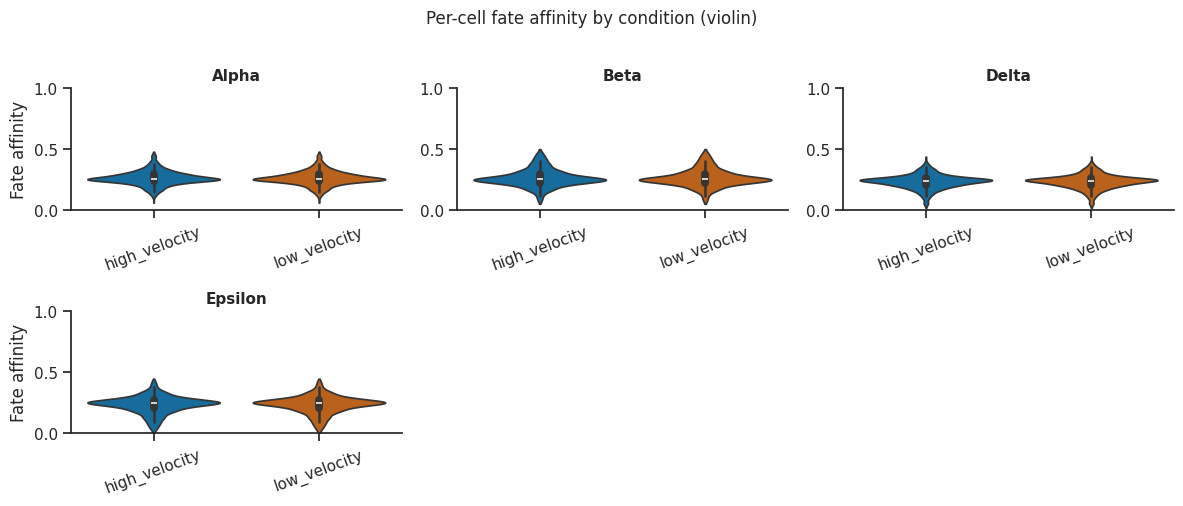

In [19]:
# Violin / box / strip plots of per-cell fate affinities
fig = mscorer.plot_condition_comparison(
    results,
    plot_type="violin",   # 'violin', 'box', or 'strip'
    figsize=(12, 5),
)
plt.tight_layout()
plt.show()

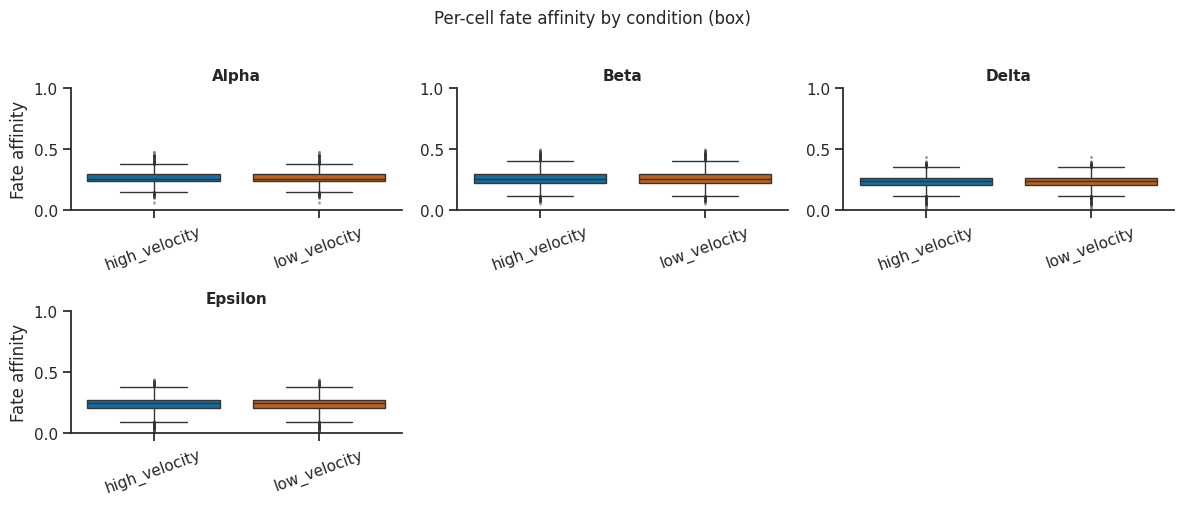

In [20]:
# Box plot version
fig = mscorer.plot_condition_comparison(
    results,
    plot_type="box",
    figsize=(12, 5),
)
plt.tight_layout()
plt.show()

## Tier 3: Trajectory-level analysis

### 3a. Mixed linear model

`fit_mixed_model()` fits a linear mixed model (via statsmodels MixedLM) for each
fate arm:

```
affinity ~ condition  (fixed effect)
         + (1 | sample)  (random effect — accounts for replicate variation)
```

This is the most rigorous approach when you have biological replicates.


In [21]:
# Fit mixed model: condition fixed effect, sample random effect
try:
    lmm_results = mscorer.fit_mixed_model(
        results,
        sample_key="sample",   # replicate column
        verbose=True,
    )

    print("\nMixed model results:")
    print(lmm_results.to_string(index=False))
except Exception as e:
    print(f"Mixed model skipped (requires statsmodels): {e}")


=== Mixed-effects model results ===
  Significant effects: 0 / 4

Mixed model results:
   fate    condition     reference          coef  std_err       z_score  pval    ci_low  ci_high  pval_adj  significant
  Alpha low_velocity high_velocity -1.479508e-20 0.001845 -8.020113e-18   1.0 -0.003616 0.003616       1.0        False
   Beta low_velocity high_velocity  1.479508e-19 0.002303  6.425574e-17   1.0 -0.004513 0.004513       1.0        False
  Delta low_velocity high_velocity -1.331557e-19 0.001849 -7.199836e-17   1.0 -0.003625 0.003625       1.0        False
Epsilon low_velocity high_velocity  1.405533e-19 0.002290  6.137928e-17   1.0 -0.004488 0.004488       1.0        False


/home/baranov_lab/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/baranov_lab/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/baranov_lab/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/baranov_lab/anaconda3/lib/python3.9/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/baranov_lab/anaconda3/lib/python3.9/site-packages/stat

### 3b. Trajectory shift analysis

`trajectory_shift()` tests whether the **pseudotime distribution** along each fate arm
differs between conditions using:
- **Kolmogorov-Smirnov (KS) test** — detects any distributional difference
- **Wasserstein distance** — quantifies the magnitude of the shift, with bootstrap CI

A significant KS test + large Wasserstein distance indicates that cells in one condition
are systematically further along (or earlier in) the differentiation trajectory.


In [22]:
# Trajectory shift analysis
# Returns a DataFrame with columns: fate, comparison, ks_stat, ks_pval,
# wasserstein, wasserstein_ci_low, wasserstein_ci_high, mean_pt_A, mean_pt_B,
# delta_mean_pt, significant
try:
    shift_df = mscorer.trajectory_shift(
        results,
        n_bootstrap=500,
        verbose=True,
    )

    print("\nTrajectory shift summary:")
    print(shift_df[["fate", "comparison", "ks_stat", "ks_pval",
                     "wasserstein", "wasserstein_ci_low", "wasserstein_ci_high",
                     "significant"]].to_string(index=False))
except Exception as e:
    print(f"Trajectory shift skipped: {e}")
    shift_df = None


=== Trajectory shift analysis ===
  Significant shifts: 3 / 3
   fate                    comparison  ks_stat  ks_pval_adj  wasserstein  delta_mean_pt
  Alpha high_velocity vs low_velocity 0.180052     0.002107     0.007711      -0.007711
   Beta high_velocity vs low_velocity 0.249283     0.000928     0.024802       0.022479
Epsilon high_velocity vs low_velocity 0.493076     0.000065     0.014575      -0.014516

Trajectory shift summary:
   fate                    comparison  ks_stat  ks_pval  wasserstein  wasserstein_ci_low  wasserstein_ci_high  significant
  Alpha high_velocity vs low_velocity 0.180052 0.000702     0.007711            0.004918             0.010952         True
   Beta high_velocity vs low_velocity 0.249283 0.000309     0.024802            0.020520             0.030387         True
Epsilon high_velocity vs low_velocity 0.493076 0.000022     0.014575            0.009233             0.020506         True


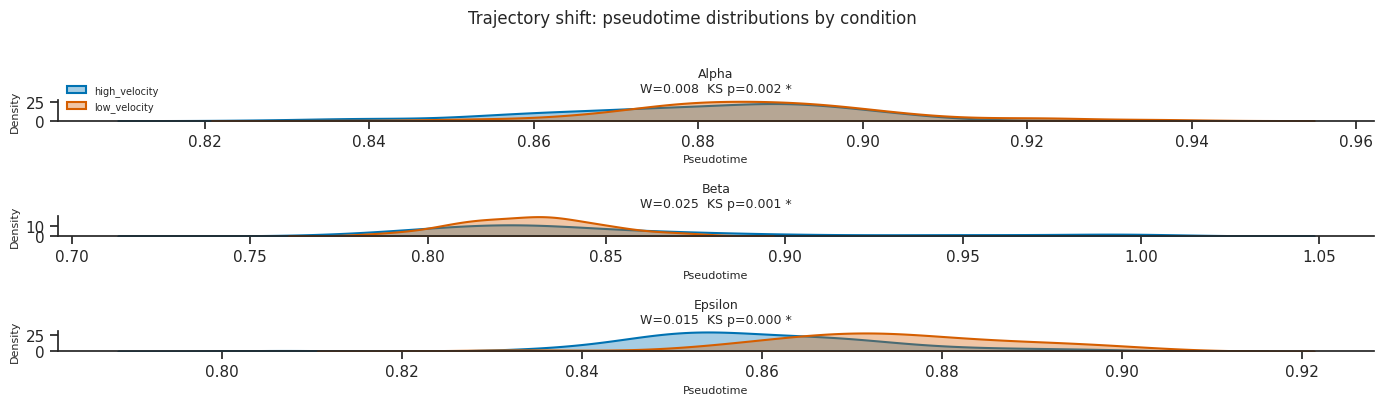

In [23]:
# KDE plots of pseudotime distributions per fate per condition
try:
    if shift_df is not None:
        fig = mscorer.plot_trajectory_shift(
            shift_df,
            figsize=(14, 4),
        )
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Trajectory shift plot skipped: {e}")

## 6. Transfer labels to full adata

`transfer_labels()` writes per-cell scores from the shared embedding back to the
full adata.  This is identical to the single-condition workflow.


[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_high_velocity_Alpha', 'cs_high_velocity_Beta', 'cs_high_velocity_Delta', 'cs_high_velocity_Epsilon', 'cs_high_velocity_dominant_fate', 'cs_high_velocity_entropy']
[scCS] Labels transferred to adata.obs for 1876 / 3696 cells. Columns: ['cs_low_velocity_Alpha', 'cs_low_velocity_Beta', 'cs_low_velocity_Delta', 'cs_low_velocity_Epsilon', 'cs_low_velocity_dominant_fate', 'cs_low_velocity_entropy']
Columns added to adata.obs: ['cs_high_velocity_Alpha', 'cs_high_velocity_Beta', 'cs_high_velocity_Delta', 'cs_high_velocity_Epsilon', 'cs_high_velocity_dominant_fate', 'cs_high_velocity_entropy', 'cs_high_velocity_nn_entropy', 'cs_low_velocity_Alpha'] ...


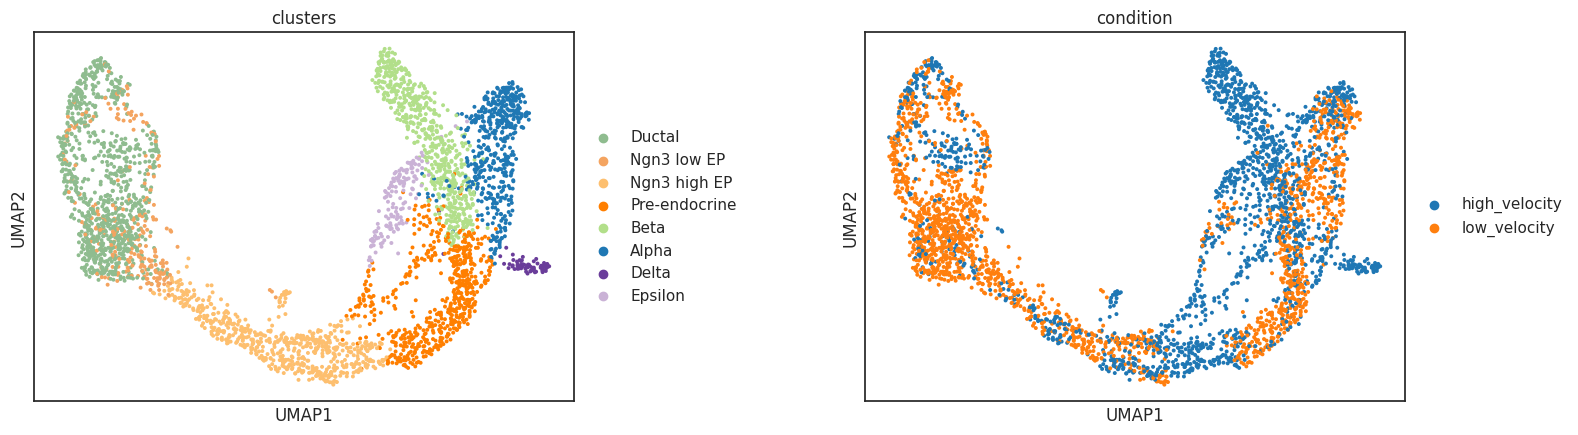

In [24]:
# Transfer per-cell scores to full adata for all conditions
# MultiConditionScorer.transfer_labels writes condition-specific columns:
# e.g., cs_high_velocity_Alpha, cs_low_velocity_Alpha, etc.
mscorer.transfer_labels(results, prefix="cs_")

# Columns added to adata.obs
cs_cols = [c for c in adata.obs.columns if c.startswith("cs_")]
print("Columns added to adata.obs:", cs_cols[:8], "...")

# Visualize on UMAP
sc.pl.umap(adata, color=["clusters", "condition"], ncols=2, wspace=0.4)

high_velocity: mean entropy = 0.974 ± 0.037
low_velocity: mean entropy = 0.974 ± 0.037


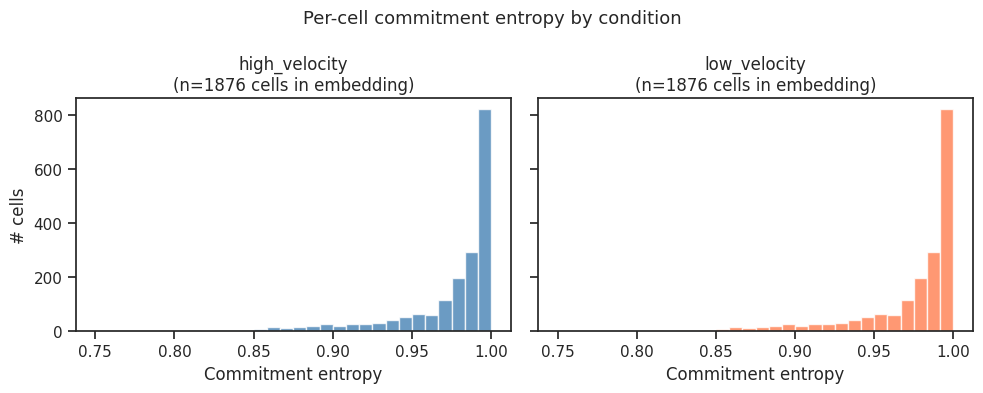

In [25]:
# Compare entropy distributions between conditions
# After transfer_labels, columns are named cs_{condition}_{fate}
# For entropy, use the per-condition results directly from adata_sub

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
colors = {"high_velocity": "steelblue", "low_velocity": "coral"}

for ax, cond in zip(axes, ["high_velocity", "low_velocity"]):
    # Get entropy from the condition-specific result
    res = results[cond]
    if res.cell_scores is not None:
        # Compute per-cell entropy from cell_scores
        k = res.cell_scores.shape[1]
        with np.errstate(divide="ignore", invalid="ignore"):
            log_s = np.where(res.cell_scores > 0, np.log(res.cell_scores), 0.0)
        ent = -np.sum(res.cell_scores * log_s, axis=1) / np.log(k)
        ax.hist(ent, bins=30, color=colors[cond], edgecolor="white", alpha=0.8)
        ax.set_title(f"{cond}\n(n={len(ent)} cells in embedding)")
        ax.set_xlabel("Commitment entropy")
        print(f"{cond}: mean entropy = {ent.mean():.3f} ± {ent.std():.3f}")
    else:
        ax.set_title(f"{cond}\n(no cell-level scores)")

axes[0].set_ylabel("# cells")
plt.suptitle("Per-cell commitment entropy by condition", fontsize=13)
plt.tight_layout()
plt.show()

## Summary — scCS multi-condition workflow

```python
import scCS

# 1. Add condition column to adata.obs (or use existing one)
adata.obs["condition"] = ...   # e.g., 'control', 'treated'
adata.obs["sample"] = ...      # biological replicates

# 2. Initialize MultiConditionScorer
mscorer = scCS.MultiConditionScorer(
    adata,
    bifurcation_cluster="Ductal",
    terminal_cell_types=["Alpha", "Beta", "Delta", "Epsilon"],
    condition_key="condition",
    cluster_key="clusters",
)

# 3. Build SHARED embedding on pooled data
mscorer.build_embedding(differentiation_metric="pseudotime")
mscorer.rebuild_embedding_with_subset_pseudotime(scale_01=False)  # preserve ordering
mscorer.fit()

# ── Tier 1: Score each condition ──────────────────────────────────────────────
results = mscorer.score_all_conditions(compute_cell_level=True, n_bootstrap=200)
mscorer.plot_condition_star(results)

# ── Tier 2: Statistical comparison ───────────────────────────────────────────
delta = mscorer.compute_delta_CS("treated", "control", n_bootstrap=500)
stats = mscorer.compare_conditions(results, n_permutations=1000)
mscorer.plot_condition_comparison(results, plot_type="violin")

# ── Tier 3: Trajectory-level analysis ────────────────────────────────────────
lmm   = mscorer.fit_mixed_model(results, sample_key="sample")
shift = mscorer.trajectory_shift(results, n_bootstrap=500)
mscorer.plot_trajectory_shift(shift)
```

### Interpretation guide

| Result | Interpretation |
|--------|---------------|
| ΔnCS > 0, CI excludes 0 | Condition A has stronger commitment toward that fate pair |
| Permutation p < 0.05 | Per-cell fate affinities differ significantly between conditions |
| LMM condition coefficient significant | Condition effect on fate affinity, controlling for replicate |
| KS p < 0.05 + large Wasserstein | Cells in one condition are systematically further along the trajectory |

For **single-condition analysis**, see: `scCS_tutorial_single_condition.ipynb`
